# Análise de uso de GPU

## Bibliotecas

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

## Nvidia RTX 5060

Experimentos que foram rodados com dois processos na máquina `172.20.72.91`.

- Cada processo rodava para uma seed diferente.
- Cada processo rodava um modelo diferente, sem paralelismo nos folds.

In [2]:
df_gpu = pd.read_csv("../gpu_log.csv")

# Remove espaços extras dos nomes das colunas
df_gpu.columns = df_gpu.columns.str.strip()

# Converte timestamp
df_gpu["timestamp"] = pd.to_datetime(df_gpu["timestamp"])

df_gpu.head()

,timestamp,index,name,utilization.gpu [%],utilization.memory [%],memory.used [MiB],memory.total [MiB],power.draw [W],power.limit [W],temperature.gpu,clocks.current.sm [MHz],clocks.current.memory [MHz]
0,2026-10-04 13:27:12.435,0,NVIDIA GeForce RTX 5060,0 %,0 %,196 MiB,8151 MiB,7.27 W,145.00 W,47,180 MHz,405 MHz
1,2026-10-04 13:27:13.445,0,NVIDIA GeForce RTX 5060,0 %,0 %,196 MiB,8151 MiB,7.30 W,145.00 W,47,180 MHz,405 MHz
2,2026-10-04 13:27:14.448,0,NVIDIA GeForce RTX 5060,0 %,0 %,196 MiB,8151 MiB,7.26 W,145.00 W,47,180 MHz,405 MHz
3,2026-10-04 13:27:15.451,0,NVIDIA GeForce RTX 5060,0 %,0 %,196 MiB,8151 MiB,7.24 W,145.00 W,47,180 MHz,405 MHz
4,2026-10-04 13:27:16.454,0,NVIDIA GeForce RTX 5060,0 %,0 %,196 MiB,8151 MiB,7.29 W,145.00 W,47,180 MHz,405 MHz


### Análise consumo de watts da GPU

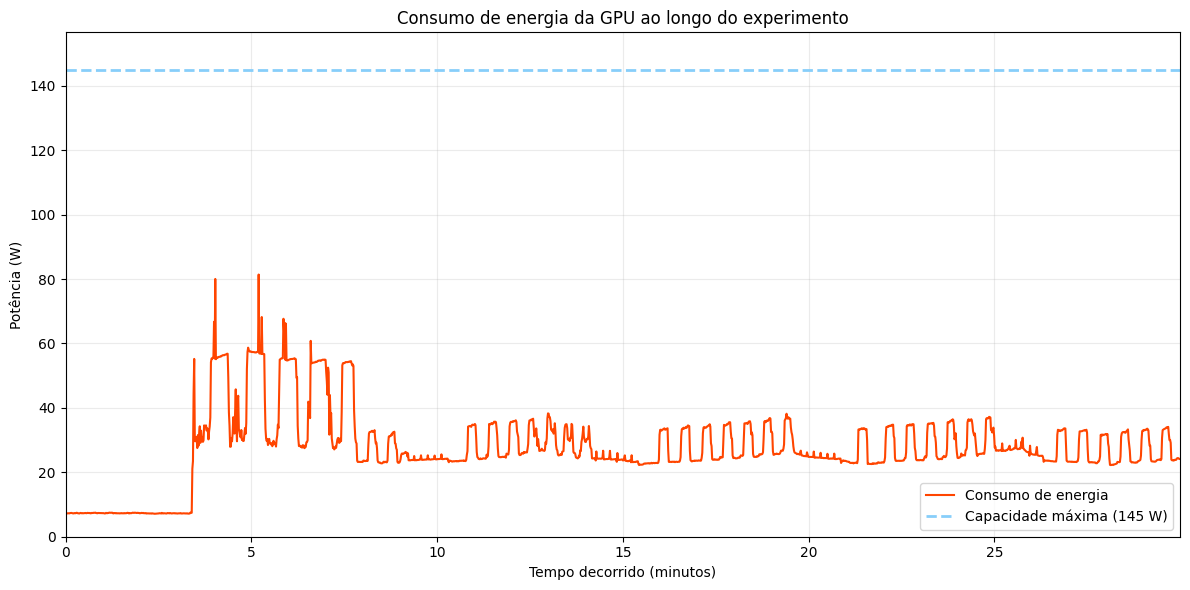

In [3]:
# Converte potência para número
df_gpu["power.draw [W]"] = (
    df_gpu["power.draw [W]"]
    .str.replace(" W", "", regex=False)
    .astype(float)
)

df_gpu["power.limit [W]"] = (
    df_gpu["power.limit [W]"]
    .str.replace(" W", "", regex=False)
    .astype(float)
)

# Tempo decorrido desde o início, em minutos
df_gpu["elapsed_min"] = (
    df_gpu["timestamp"] - df_gpu["timestamp"].iloc[0]
).dt.total_seconds() / 60

# Capacidade máxima da GPU
power_limit = df_gpu["power.limit [W]"].iloc[0]

plt.figure(figsize=(12, 6))

# Consumo real
plt.plot(
    df_gpu["elapsed_min"],
    df_gpu["power.draw [W]"],
    color="orangered",
    linewidth=1.5,
    label="Consumo de energia"
)

# Limite máximo
plt.axhline(
    y=power_limit,
    color="lightskyblue",
    linestyle="--",
    linewidth=2,
    label=f"Capacidade máxima ({power_limit:.0f} W)"
)

plt.xlabel("Tempo decorrido (minutos)")
plt.ylabel("Potência (W)")
plt.title("Consumo de energia da GPU ao longo do experimento")

plt.xlim(df_gpu["elapsed_min"].min(), df_gpu["elapsed_min"].max())
plt.ylim(0, power_limit * 1.08)

plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()

plt.show()

### Analisando o consumo de memória da GPU

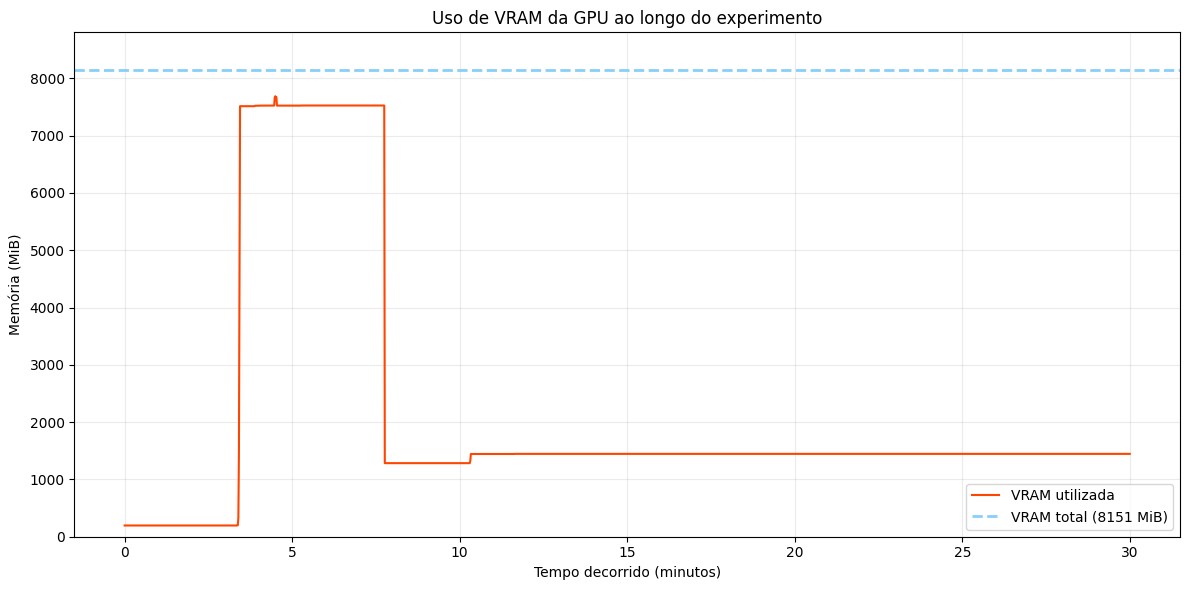

In [4]:
# Remove unidades e converte para float
df_gpu["memory.used [MiB]"] = (
    df_gpu["memory.used [MiB]"]
    .str.replace(" MiB", "", regex=False)
    .astype(float)
)

df_gpu["memory.total [MiB]"] = (
    df_gpu["memory.total [MiB]"]
    .str.replace(" MiB", "", regex=False)
    .astype(float)
)

# Tempo desde o início em minutos
df_gpu["elapsed_min"] = (
    df_gpu["timestamp"] - df_gpu["timestamp"].iloc[0]
).dt.total_seconds() / 60

memory_total = df_gpu["memory.total [MiB]"].iloc[0]

plt.figure(figsize=(12, 6))

# VRAM usada
plt.plot(
    df_gpu["elapsed_min"],
    df_gpu["memory.used [MiB]"],
    color="orangered",
    linewidth=1.5,
    label="VRAM utilizada"
)

# Capacidade máxima
plt.axhline(
    memory_total,
    color="lightskyblue",
    linestyle="--",
    linewidth=2,
    label=f"VRAM total ({memory_total:.0f} MiB)"
)

plt.xlabel("Tempo decorrido (minutos)")
plt.ylabel("Memória (MiB)")
plt.title("Uso de VRAM da GPU ao longo do experimento")

plt.ylim(0, memory_total * 1.08)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

plt.show()